# Big Data Web Log Analysis using Apache Spark

## Objectif
Ce projet analyse les logs HTTP du serveur web de la NASA (juillet et août 1995) 
afin de comprendre le comportement des utilisateurs, identifier les pages les 
plus visitées et analyser les erreurs du serveur.

Technologies utilisées :
- Apache Spark
- PySpark
- Python
- Power BI (pour la visualisation)

In [1]:
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
import pandas as pd
import matplotlib.pyplot as plt

## Initialisation de la session Spark
On crée une SparkSession pour traiter les données Big Data.

In [2]:
import os

os.environ["JAVA_HOME"] = "C:\\Java\\jdk-11.0.26"
os.environ["SPARK_HOME"] = "C:\\spark\\spark-3.5.8-bin-hadoop3"
os.environ["HADOOP_HOME"] = "C:\\hadoop"

os.environ["PYSPARK_SUBMIT_ARGS"] = "--master local[*] pyspark-shell"

In [3]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .master("local[*]") \
    .appName("NASA_Web_Log_Analysis") \
    .getOrCreate()

spark

## Load Dataset

Nous chargeons les logs web du serveur NASA pour juillet et août 1995.
Chaque ligne du dataset représente une requête HTTP.

In [4]:
log_july = spark.read.text("file:///C:/Users/pc/Desktop/projet big data/access_log_Jul95")
log_aug = spark.read.text("file:///C:/Users/pc/Desktop/projet big data/access_log_Aug95")

logs = log_july.union(log_aug)

logs.show(5, False)

+-----------------------------------------------------------------------------------------------------------------------+
|value                                                                                                                  |
+-----------------------------------------------------------------------------------------------------------------------+
|199.72.81.55 - - [01/Jul/1995:00:00:01 -0400] "GET /history/apollo/ HTTP/1.0" 200 6245                                 |
|unicomp6.unicomp.net - - [01/Jul/1995:00:00:06 -0400] "GET /shuttle/countdown/ HTTP/1.0" 200 3985                      |
|199.120.110.21 - - [01/Jul/1995:00:00:09 -0400] "GET /shuttle/missions/sts-73/mission-sts-73.html HTTP/1.0" 200 4085   |
|burger.letters.com - - [01/Jul/1995:00:00:11 -0400] "GET /shuttle/countdown/liftoff.html HTTP/1.0" 304 0               |
|199.120.110.21 - - [01/Jul/1995:00:00:11 -0400] "GET /shuttle/missions/sts-73/sts-73-patch-small.gif HTTP/1.0" 200 4179|
+-----------------------

## Data Parsing
In this step, we extract useful information from raw NASA logs using regular expressions.

In [5]:
from pyspark.sql.functions import regexp_extract

logs_df = logs.select(
    regexp_extract("value", r'^(\S+)', 1).alias("IP"),
    regexp_extract("value", r'\[(.*?)\]', 1).alias("Timestamp"),
    regexp_extract("value", r'"(\S+)', 1).alias("Method"),
    regexp_extract("value", r'"(?:\S+)\s(\S+)', 1).alias("Endpoint"),
    regexp_extract("value", r'\s(\d{3})\s', 1).alias("Status"),
    regexp_extract("value", r'\s(\d+)$', 1).alias("Size")
)

In [6]:
logs_df.show(5, False)

+--------------------+--------------------------+------+-----------------------------------------------+------+----+
|IP                  |Timestamp                 |Method|Endpoint                                       |Status|Size|
+--------------------+--------------------------+------+-----------------------------------------------+------+----+
|199.72.81.55        |01/Jul/1995:00:00:01 -0400|GET   |/history/apollo/                               |200   |6245|
|unicomp6.unicomp.net|01/Jul/1995:00:00:06 -0400|GET   |/shuttle/countdown/                            |200   |3985|
|199.120.110.21      |01/Jul/1995:00:00:09 -0400|GET   |/shuttle/missions/sts-73/mission-sts-73.html   |200   |4085|
|burger.letters.com  |01/Jul/1995:00:00:11 -0400|GET   |/shuttle/countdown/liftoff.html                |304   |0   |
|199.120.110.21      |01/Jul/1995:00:00:11 -0400|GET   |/shuttle/missions/sts-73/sts-73-patch-small.gif|200   |4179|
+--------------------+--------------------------+------+--------

## Data Cleaning
This step includes converting data types, handling missing values, and verifying the dataset structure.

### Dataset Schema

First, we inspect the schema of the dataset to understand the data types of each column.

In [7]:
logs_df.printSchema()

root
 |-- IP: string (nullable = true)
 |-- Timestamp: string (nullable = true)
 |-- Method: string (nullable = true)
 |-- Endpoint: string (nullable = true)
 |-- Status: string (nullable = true)
 |-- Size: string (nullable = true)



### Converting Data Types

The `Status` and `Size` columns are extracted as strings during the parsing step.  
Since they represent numeric values, we convert them to integer type for further analysis.

In [8]:
logs_df = logs_df.withColumn("Status", logs_df["Status"].cast("int"))
logs_df = logs_df.withColumn("Size", logs_df["Size"].cast("int"))

In [9]:
logs_df.printSchema()

root
 |-- IP: string (nullable = true)
 |-- Timestamp: string (nullable = true)
 |-- Method: string (nullable = true)
 |-- Endpoint: string (nullable = true)
 |-- Status: integer (nullable = true)
 |-- Size: integer (nullable = true)



### Handling Missing Values

Some log entries may contain missing values for the response size.  
We check for null values in the dataset.

In [10]:
logs_df.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c)
    for c in logs_df.columns
]).show()

+---+---------+------+--------+------+-----+
| IP|Timestamp|Method|Endpoint|Status| Size|
+---+---------+------+--------+------+-----+
|  0|        0|     0|       0|     1|33905|
+---+---------+------+--------+------+-----+



The dataset does not contain missing values in the columns IP, Timestamp, Method, and Endpoint. However, we found 1 missing value in the Status column and 33905 missing values in the Size column, which is common in web server logs when the response size is not recorded.

## Exploratory Data Analysis (EDA)

In this section, we analyze the NASA web server logs to understand traffic patterns and user behavior.  
We will explore the most requested resources, the most active users, and the distribution of HTTP status codes.

### Total Number of Requests

In [11]:
logs_df.count()

3461613

### Top 10 Most Requested Endpoints

This analysis identifies the most frequently accessed resources on the NASA website.

In [12]:
logs_df.groupBy("Endpoint") \
.count() \
.orderBy(F.desc("count")) \
.show(10)

+--------------------+------+
|            Endpoint| count|
+--------------------+------+
|/images/NASA-logo...|208437|
|/images/KSC-logos...|164813|
|/images/MOSAIC-lo...|127656|
|/images/USA-logos...|126820|
|/images/WORLD-log...|125676|
|/images/ksclogo-m...|121286|
|           /ksc.html| 83691|
|/images/launch-lo...| 75960|
|/history/apollo/i...| 68858|
| /shuttle/countdown/| 64696|
+--------------------+------+
only showing top 10 rows



### Top 10 Most Active IP Addresses

In [13]:
logs_df.groupBy("IP") \
.count() \
.orderBy(F.desc("count")) \
.show(10)

+--------------------+-----+
|                  IP|count|
+--------------------+-----+
|piweba3y.prodigy.com|21988|
|piweba4y.prodigy.com|16437|
|piweba1y.prodigy.com|12825|
|  edams.ksc.nasa.gov|11964|
|        163.206.89.4| 9697|
|         news.ti.com| 8161|
|www-d1.proxy.aol.com| 8047|
|  alyssa.prodigy.com| 8037|
| siltb10.orl.mmc.com| 7573|
|www-a2.proxy.aol.com| 7516|
+--------------------+-----+
only showing top 10 rows



### HTTP Status Code Distribution

In [14]:
logs_df.groupBy("Status") \
.count() \
.orderBy("Status") \
.show()

+------+-------+
|Status|  count|
+------+-------+
|  NULL|      1|
|   200|3100524|
|   302|  73070|
|   304| 266773|
|   400|     15|
|   403|    225|
|   404|  20899|
|   500|     65|
|   501|     41|
+------+-------+



### Analysis of HTTP 404 Errors

HTTP 404 errors occur when a requested resource cannot be found.  
Analyzing these errors helps identify broken links or missing resources.

In [15]:
errors_404 = logs_df.filter(logs_df.Status == 404)

errors_404.count()

20899

In [21]:
error_rate = (errors_404.count() / logs_df.count() * 100)
print(error_rate)

0.6037358884427577


In [16]:
errors_404.groupBy("Endpoint") \
.count() \
.orderBy(F.desc("count")) \
.show(10)

+--------------------+-----+
|            Endpoint|count|
+--------------------+-----+
|/pub/winvn/readme...| 2004|
|/pub/winvn/releas...| 1732|
|/shuttle/missions...|  682|
|/shuttle/missions...|  426|
|/history/apollo/a...|  384|
|/history/apollo/s...|  383|
|/://spacelink.msf...|  381|
|/images/crawlerwa...|  374|
|/elv/DELTA/uncons...|  372|
|/history/apollo/p...|  359|
+--------------------+-----+
only showing top 10 rows



### Timestamp Conversion

The timestamp column is converted into a proper datetime format to analyze traffic patterns over time.

In [17]:
from pyspark.sql.functions import to_timestamp

logs_df = logs_df.withColumn(
    "Timestamp",
    to_timestamp("Timestamp", "dd/MMM/yyyy:HH:mm:ss")
)

### Daily Traffic Analysis

This analysis shows the number of requests received each day.

In [19]:
from pyspark.sql.functions import to_date
from pyspark.sql.functions import to_timestamp

logs_df = logs_df.withColumn(
    "Timestamp",
    to_timestamp("Timestamp", "dd/MMM/yyyy:HH:mm:ss Z")
)

### Traffic by Hour

This analysis identifies peak hours of activity on the NASA website.

In [45]:
from pyspark.sql.functions import split

logs_df = logs_df.withColumn(
    "Timestamp_clean",
    split("Timestamp", " ").getItem(0)
)

In [46]:
from pyspark.sql.functions import to_timestamp

logs_df = logs_df.withColumn(
    "Timestamp_parsed",
    to_timestamp("Timestamp_clean", "dd/MMM/yyyy:HH:mm:ss")
)

In [47]:
logs_df.select("Timestamp","Timestamp_clean","Timestamp_parsed").show(5, False)

+--------------------------+--------------------+-------------------+
|Timestamp                 |Timestamp_clean     |Timestamp_parsed   |
+--------------------------+--------------------+-------------------+
|01/Jul/1995:00:00:01 -0400|01/Jul/1995:00:00:01|1995-07-01 00:00:01|
|01/Jul/1995:00:00:06 -0400|01/Jul/1995:00:00:06|1995-07-01 00:00:06|
|01/Jul/1995:00:00:09 -0400|01/Jul/1995:00:00:09|1995-07-01 00:00:09|
|01/Jul/1995:00:00:11 -0400|01/Jul/1995:00:00:11|1995-07-01 00:00:11|
|01/Jul/1995:00:00:11 -0400|01/Jul/1995:00:00:11|1995-07-01 00:00:11|
+--------------------------+--------------------+-------------------+
only showing top 5 rows



In [48]:
from pyspark.sql.functions import hour, to_date

logs_df = logs_df.withColumn("Date", to_date("Timestamp_parsed"))
logs_df = logs_df.withColumn("Hour", hour("Timestamp_parsed"))

In [49]:
logs_df.select("Timestamp_parsed","Date","Hour").show(5)

+-------------------+----------+----+
|   Timestamp_parsed|      Date|Hour|
+-------------------+----------+----+
|1995-07-01 00:00:01|1995-07-01|   0|
|1995-07-01 00:00:06|1995-07-01|   0|
|1995-07-01 00:00:09|1995-07-01|   0|
|1995-07-01 00:00:11|1995-07-01|   0|
|1995-07-01 00:00:11|1995-07-01|   0|
+-------------------+----------+----+
only showing top 5 rows



In [50]:
traffic_by_hour = logs_df.groupBy("Hour") \
.count() \
.orderBy("Hour")

traffic_by_hour.show()

+----+------+
|Hour| count|
+----+------+
|NULL|     1|
|   0|110312|
|   1| 91597|
|   2| 77805|
|   3| 67393|
|   4| 58990|
|   5| 59506|
|   6| 66540|
|   7|101403|
|   8|149193|
|   9|178664|
|  10|193816|
|  11|211064|
|  12|227228|
|  13|225350|
|  14|223873|
|  15|230665|
|  16|217564|
|  17|178443|
|  18|146091|
+----+------+
only showing top 20 rows



In [51]:
traffic_by_hour = logs_df.filter(logs_df.Hour.isNotNull()) \
.groupBy("Hour") \
.count() \
.orderBy("Hour")

traffic_by_hour.show()

+----+------+
|Hour| count|
+----+------+
|   0|110312|
|   1| 91597|
|   2| 77805|
|   3| 67393|
|   4| 58990|
|   5| 59506|
|   6| 66540|
|   7|101403|
|   8|149193|
|   9|178664|
|  10|193816|
|  11|211064|
|  12|227228|
|  13|225350|
|  14|223873|
|  15|230665|
|  16|217564|
|  17|178443|
|  18|146091|
|  19|131091|
+----+------+
only showing top 20 rows



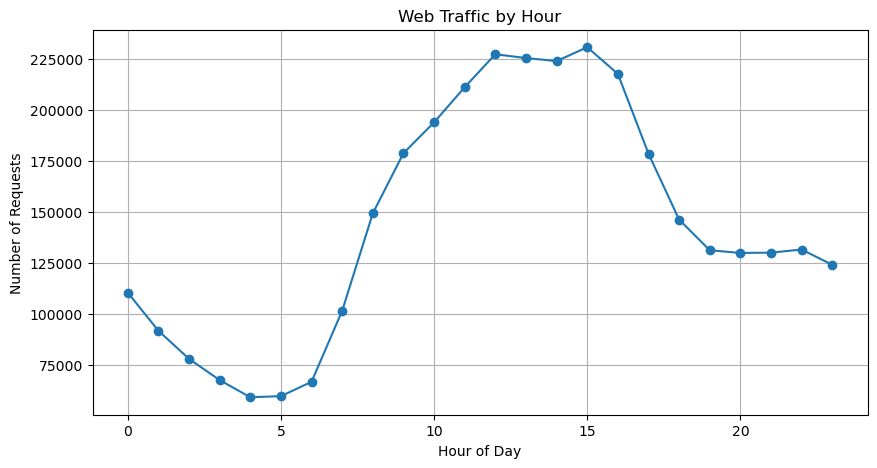

In [52]:
import matplotlib.pyplot as plt

pdf = traffic_by_hour.toPandas()

plt.figure(figsize=(10,5))
plt.plot(pdf["Hour"], pdf["count"], marker='o')
plt.title("Web Traffic by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Requests")
plt.grid(True)
plt.show()

The graph shows the distribution of web requests across different hours of the day.

We observe that the traffic is relatively low during the early morning hours (between 2 AM and 6 AM).
The number of requests begins to increase in the morning and reaches its peak between 12 PM and 3 PM.

This pattern indicates that most users access the website during typical daytime working hours.
After 4 PM, the traffic gradually decreases until the night.

### Daily Traffic Trend

This analysis shows the evolution of web traffic over time.
It helps identify trends, anomalies, or sudden spikes in activity.

In [53]:
traffic_by_day = logs_df.groupBy("Date") \
.count() \
.orderBy("Date")

traffic_by_day.show()

+----------+------+
|      Date| count|
+----------+------+
|      NULL|     1|
|1995-07-01| 64714|
|1995-07-02| 60265|
|1995-07-03| 89584|
|1995-07-04| 70452|
|1995-07-05| 94575|
|1995-07-06|100960|
|1995-07-07| 87233|
|1995-07-08| 38867|
|1995-07-09| 35272|
|1995-07-10| 72860|
|1995-07-11| 80407|
|1995-07-12| 92536|
|1995-07-13|134203|
|1995-07-14| 84103|
|1995-07-15| 45532|
|1995-07-16| 47854|
|1995-07-17| 74981|
|1995-07-18| 64282|
|1995-07-19| 72738|
+----------+------+
only showing top 20 rows



In [54]:
traffic_by_day = logs_df.filter(logs_df.Date.isNotNull()) \
.groupBy("Date") \
.count() \
.orderBy("Date")

traffic_by_day.show()

+----------+------+
|      Date| count|
+----------+------+
|1995-07-01| 64714|
|1995-07-02| 60265|
|1995-07-03| 89584|
|1995-07-04| 70452|
|1995-07-05| 94575|
|1995-07-06|100960|
|1995-07-07| 87233|
|1995-07-08| 38867|
|1995-07-09| 35272|
|1995-07-10| 72860|
|1995-07-11| 80407|
|1995-07-12| 92536|
|1995-07-13|134203|
|1995-07-14| 84103|
|1995-07-15| 45532|
|1995-07-16| 47854|
|1995-07-17| 74981|
|1995-07-18| 64282|
|1995-07-19| 72738|
|1995-07-20| 66593|
+----------+------+
only showing top 20 rows



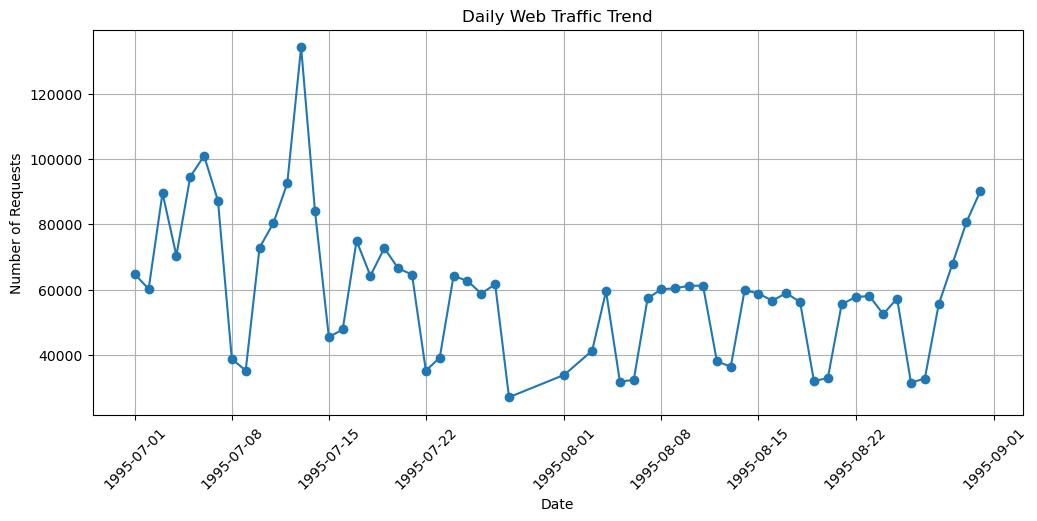

In [55]:
import matplotlib.pyplot as plt

pdf_day = traffic_by_day.toPandas()

plt.figure(figsize=(12,5))
plt.plot(pdf_day["Date"], pdf_day["count"], marker='o')
plt.title("Daily Web Traffic Trend")
plt.xlabel("Date")
plt.ylabel("Number of Requests")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

The graph shows the evolution of the number of web requests over time.

We observe that the traffic fluctuates significantly between different days.
Some days experience high peaks in traffic, while others show a noticeable drop in activity.

For example, a major traffic peak occurs around mid-July, where the number of requests exceeds 130,000 requests in a single day.

In contrast, several days in late July and early August show lower activity levels.
These variations may be due to user behavior patterns, server activity changes, or external events affecting website usage.

### Most Requested Resources

In [56]:
top_pages = logs_df.groupBy("Endpoint") \
.count() \
.orderBy("count", ascending=False) \
.limit(10)

top_pages.show()

+--------------------+------+
|            Endpoint| count|
+--------------------+------+
|/images/NASA-logo...|208437|
|/images/KSC-logos...|164813|
|/images/MOSAIC-lo...|127656|
|/images/USA-logos...|126820|
|/images/WORLD-log...|125676|
|/images/ksclogo-m...|121286|
|           /ksc.html| 83691|
|/images/launch-lo...| 75960|
|/history/apollo/i...| 68858|
| /shuttle/countdown/| 64696|
+--------------------+------+



### 404 Error Analysis

In [57]:
errors_404 = logs_df.filter(logs_df.Status == 404) \
.groupBy("Endpoint") \
.count() \
.orderBy("count", ascending=False) \
.limit(10)

errors_404.show()

+--------------------+-----+
|            Endpoint|count|
+--------------------+-----+
|/pub/winvn/readme...| 2004|
|/pub/winvn/releas...| 1732|
|/shuttle/missions...|  682|
|/shuttle/missions...|  426|
|/history/apollo/a...|  384|
|/history/apollo/s...|  383|
|/://spacelink.msf...|  381|
|/images/crawlerwa...|  374|
|/elv/DELTA/uncons...|  372|
|/history/apollo/p...|  359|
+--------------------+-----+



### Top Users by IP Address

In [13]:
top_users_ip = logs_df.groupBy("IP") \
                     .count() \
                     .orderBy("count", ascending=False)

In [14]:
top_users_ip.show(10)

+--------------------+-----+
|                  IP|count|
+--------------------+-----+
|piweba3y.prodigy.com|21988|
|piweba4y.prodigy.com|16437|
|piweba1y.prodigy.com|12825|
|  edams.ksc.nasa.gov|11964|
|        163.206.89.4| 9697|
|         news.ti.com| 8161|
|www-d1.proxy.aol.com| 8047|
|  alyssa.prodigy.com| 8037|
| siltb10.orl.mmc.com| 7573|
|www-a2.proxy.aol.com| 7516|
+--------------------+-----+
only showing top 10 rows



### Top HTTP Methods

In [23]:
methods_df = logs_df.filter(
    logs_df.Method.isin("GET", "HEAD", "POST", "PUT", "DELETE")
).groupBy("Method") \
 .count() \
 .orderBy("count", ascending=False)

methods_df.show()

+------+-------+
|Method|  count|
+------+-------+
|   GET|3453458|
|  HEAD|   7917|
|  POST|    222|
+------+-------+



### Status Code Distribution

In [27]:
status_df = logs_df.filter(logs_df.Status.isNotNull()) \
    .groupBy("Status") \
    .count() \
    .orderBy("count", ascending=False)

status_df.show()

+------+-------+
|Status|  count|
+------+-------+
|   200|3100524|
|   304| 266773|
|   302|  73070|
|   404|  20899|
|   403|    225|
|   500|     65|
|   501|     41|
|   400|     15|
+------+-------+



## Exporting Results for Power BI Dashboard

The aggregated datasets (traffic by hour, traffic by day, top endpoints,
and 404 errors) were exported as CSV files to be visualized in Power BI.

In [59]:
traffic_by_hour.coalesce(1).write \
.mode("overwrite") \
.option("header", True) \
.csv("file:///C:/Users/pc/Desktop/projet big data/output/traffic_by_hour")

In [60]:
traffic_by_day.coalesce(1).write \
.mode("overwrite") \
.option("header", True) \
.csv("file:///C:/Users/pc/Desktop/projet big data/output/traffic_by_day")

In [61]:
top_pages.coalesce(1).write \
.mode("overwrite") \
.option("header", True) \
.csv("file:///C:/Users/pc/Desktop/projet big data/output/top_pages")

In [62]:
errors_404.coalesce(1).write \
.mode("overwrite") \
.option("header", True) \
.csv("file:///C:/Users/pc/Desktop/projet big data/output/errors_404")

In [16]:
top_users_ip.coalesce(1).write \
.mode("overwrite") \
.option("header", True) \
.csv("file:///C:/Users/pc/Desktop/projet big data/output/top_users_ip")

In [25]:
methods_df.coalesce(1).write \
.mode("overwrite") \
.option("header", True) \
.csv("file:///C:/Users/pc/Desktop/projet big data/output/top_http_methods")

In [29]:
status_df.coalesce(1).write \
.mode("overwrite") \
.option("header", True) \
.csv("file:///C:/Users/pc/Desktop/projet big data/output/status_distribution")

## Conclusion

In this project, we analyzed NASA web server logs using PySpark to understand website traffic patterns.

The analysis included log parsing, data cleaning, feature engineering, and traffic analysis through several aggregations and visualizations.

Key insights include:
- Identification of peak traffic hours during the day
- Detection of daily traffic trends
- Identification of the most requested resources
- Analysis of HTTP status codes and 404 errors
- Identificaion of Top users by IP Address
- Identification of Top HTTP Methods
- Identification of Status Code Distribution

This project demonstrates how large-scale web logs can be processed and analyzed using big data tools such as PySpark.